In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [2]:
# !wget https://archive.ics.uci.edu/static/public/176/blood+transfusion+service+center.zip
# !unzip blood+transfusion+service+center.zip

In [3]:
# !unzip census+income.zip

In [4]:
# !pip install openml

In [5]:
import pandas as pd

df = pd.read_csv('transfusion.data', sep=',')
print(len(df))
df

748


,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
...,...,...,...,...,...
743,23,2,500,38,0
744,21,2,500,52,0
745,23,3,750,62,0
746,39,1,250,39,0


In [6]:
df.columns

Index(['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)',
       'Time (months)', 'whether he/she donated blood in March 2007'],
      dtype='object')

In [7]:
import numpy as np
import torch

DROP_P = 0.2

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'

    text = "".join([f"I have information about a blood donor. For the first time he donated blood {x['Time (months)']} months ago. ",
           f"Last time he donated blood {x['Recency (months)']} months ago. ",
           f"In total he donated blood {x['Frequency (times)']} times and donated {x['Monetary (c.c. blood)']} cubic centimeters of blood. ",
           f"Will this person donate blood in the next month?"])

    return text

concatenate_text(df.iloc[0])

'I have information about a blood donor. For the first time he donated blood 98 months ago. Last time he donated blood 2 months ago. In total he donated blood [UNK] times and donated 12500 cubic centimeters of blood. Will this person donate blood in the next month?'

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('whether he/she donated blood in March 2007', axis =1),
                                                    df['whether he/she donated blood in March 2007'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({'yes': 1, 'no': 0})
# y_test = y_test.replace({'yes': 1, 'no': 0})

X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

In [9]:
X_train['text'].iloc[0]

'I have information about a blood donor. For the first time he donated blood 49 months ago. Last time he donated blood 9 months ago. In total he donated blood [UNK] times and donated 2750 cubic centimeters of blood. Will this person donate blood in the next month?'

In [10]:
len(X_train)

598

In [11]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
# id2label = {0: "NOT-DONATE", 1: "DONATE"}
# label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [12]:
tokenized_train_dataset[0].keys()

dict_keys(['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)', 'Time (months)', 'label', 'text', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [13]:
tokenized_train_dataset[0]['text']

'I have information about a blood donor. For the first time he donated blood 49 months ago. Last time he donated blood 9 months ago. In total he donated blood [UNK] times and donated 2750 cubic centimeters of blood. Will this person donate blood in the next month?'

In [14]:
tokenized_train_dataset[0]['label']

1

In [15]:
import torch
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")
    

tensor([1.], device='mps:0')


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 8.8507, 'grad_norm': 18.9678897857666, 'learning_rate': 0.095, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.7533333333333333
test roc_auc 0.6388423822052142



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7642140468227425
train roc_auc 0.664315533001226


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


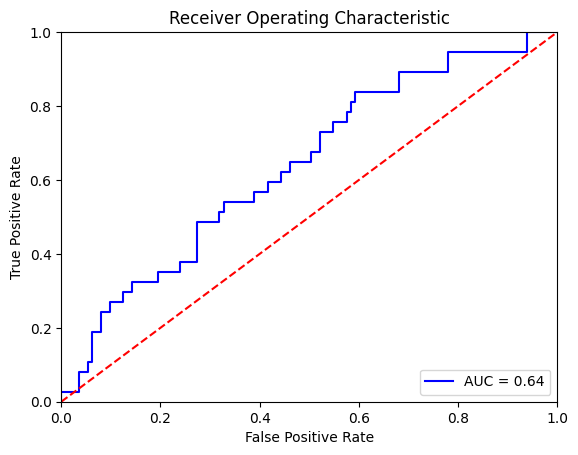

In [16]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

def find_best_threshold(y_true, y_pred):
    best_threshold = 0.0
    best_f1 = 0.0
    best_accuracy = 0.0
    
    thresholds = np.arange(0.0, 1.01, 0.01)
    for threshold in thresholds:
        y_pred_binary = (y_pred >= threshold).astype(int)
        
        current_f1 = f1_score(y_true, y_pred_binary)
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold
            best_accuracy = accuracy_score(y_true, y_pred_binary)
    
    return best_f1, best_threshold

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.5432, 'grad_norm': 4.3699493408203125, 'learning_rate': 2.0000000000000002e-07, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.5526350736618042, 'eval_roc_auc': 0.6280794068404689, 'eval_runtime': 1.1693, 'eval_samples_per_second': 128.282, 'eval_steps_per_second': 2.566, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.45161290322580644
test precision 0.56
test recall 0.3783783783783784
test accuracy 0.7733333333333333
test roc_auc 0.72662042573547



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.5187713310580204
train precision 0.5
train recall 0.5390070921985816
train accuracy 0.7642140468227425
train roc_auc 0.7618371432562038


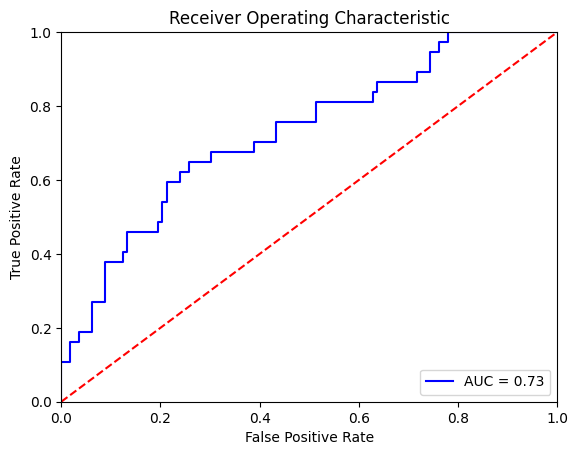

In [17]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [18]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.7252±0.0495',
 'F1': '0.4488±0.0799',
 'Accuracy': '0.7739±0.0334',
 'Precision': '0.5632±0.1009',
 'Recall': '0.3784±0.0807'}

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.7533333333333333
test roc_auc 0.6414733317388185



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7642140468227425
train roc_auc 0.549257414218539


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


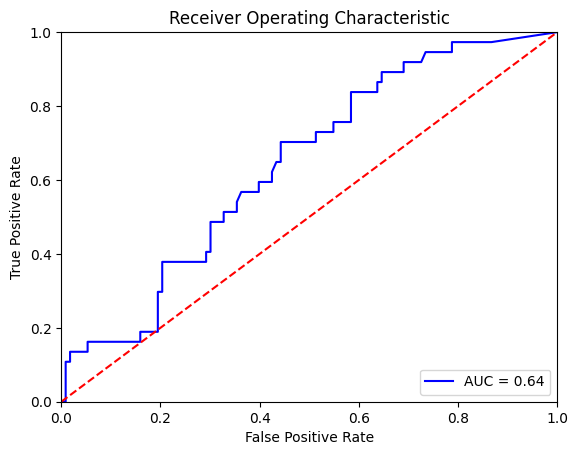

In [19]:
DROP_P = 0.5

X_train, X_test, y_train, y_test = train_test_split(df.drop('whether he/she donated blood in March 2007', axis =1),
                                                    df['whether he/she donated blood in March 2007'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({'yes': 1, 'no': 0})
# y_test = y_test.replace({'yes': 1, 'no': 0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.5614, 'grad_norm': 4.544617652893066, 'learning_rate': 2.0000000000000002e-07, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.5626793503761292, 'eval_roc_auc': 0.6546280794068404, 'eval_runtime': 1.1747, 'eval_samples_per_second': 127.694, 'eval_steps_per_second': 2.554, 'epoch': 1.0}


...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.7533333333333333
test roc_auc 0.6969624491748385



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7642140468227425
train roc_auc 0.6226779645234881


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


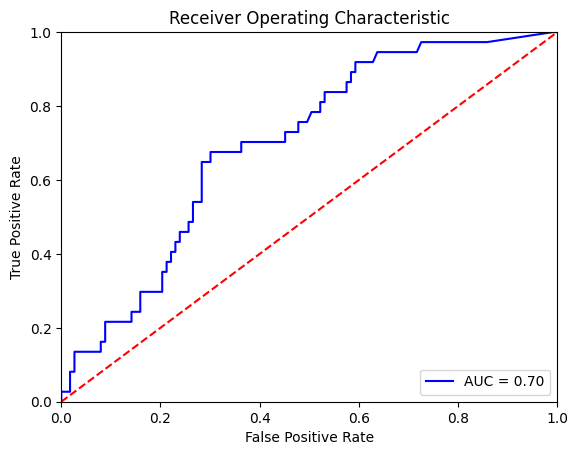

In [20]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [21]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.6960±0.0452',
 'F1': '0.0000±0.0000',
 'Accuracy': '0.7528±0.0339',
 'Precision': '0.0000±0.0000',
 'Recall': '0.0000±0.0000'}

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.7533333333333333
test roc_auc 0.5656541497249462



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7642140468227425
train roc_auc 0.5073637816782284


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


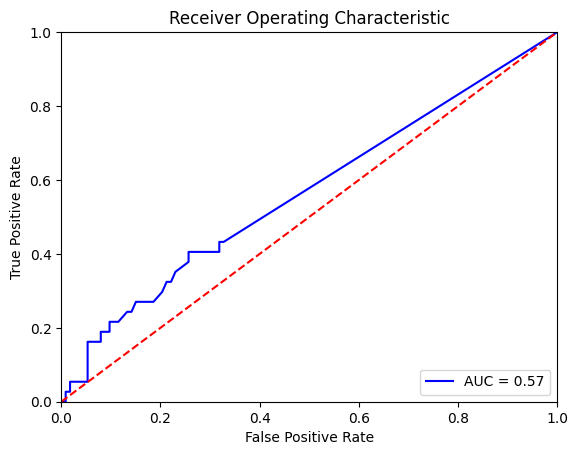

In [22]:
DROP_P = 0.9

X_train, X_test, y_train, y_test = train_test_split(df.drop('whether he/she donated blood in March 2007', axis =1),
                                                    df['whether he/she donated blood in March 2007'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({'yes': 1, 'no': 0})
# y_test = y_test.replace({'yes': 1, 'no': 0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.5327, 'grad_norm': 5.492753028869629, 'learning_rate': 2.0000000000000002e-07, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.55620276927948, 'eval_roc_auc': 0.5670892131069122, 'eval_runtime': 1.1757, 'eval_samples_per_second': 127.588, 'eval_steps_per_second': 2.552, 'epoch': 1.0}


...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.7533333333333333
test roc_auc 0.5682850992585505



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7642140468227425
train roc_auc 0.5143783850893121


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


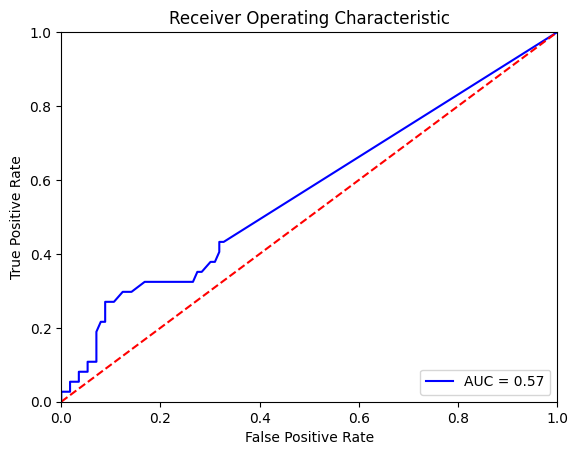

In [23]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [24]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.5672±0.0489',
 'F1': '0.0000±0.0000',
 'Accuracy': '0.7528±0.0339',
 'Precision': '0.0000±0.0000',
 'Recall': '0.0000±0.0000'}

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.7533333333333333
test roc_auc 0.7089213106912222



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7642140468227425
train roc_auc 0.6656424104163758


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


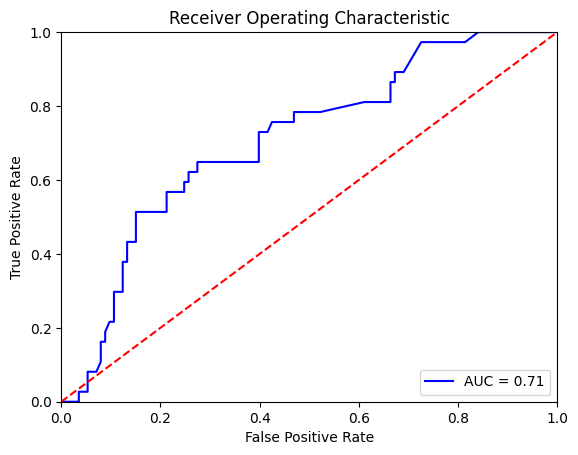

In [25]:
DROP_P = 0

X_train, X_test, y_train, y_test = train_test_split(df.drop('whether he/she donated blood in March 2007', axis =1),
                                                    df['whether he/she donated blood in March 2007'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({'yes': 1, 'no': 0})
# y_test = y_test.replace({'yes': 1, 'no': 0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.5346, 'grad_norm': 3.50032114982605, 'learning_rate': 2.0000000000000002e-07, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.5512025952339172, 'eval_roc_auc': 0.7055728294666348, 'eval_runtime': 1.1722, 'eval_samples_per_second': 127.96, 'eval_steps_per_second': 2.559, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.4927536231884058
test precision 0.53125
test recall 0.4594594594594595
test accuracy 0.7666666666666667
test roc_auc 0.7239894762018655



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.5
train precision 0.46107784431137727
train recall 0.5460992907801419
train accuracy 0.7424749163879598
train roc_auc 0.762605335443922


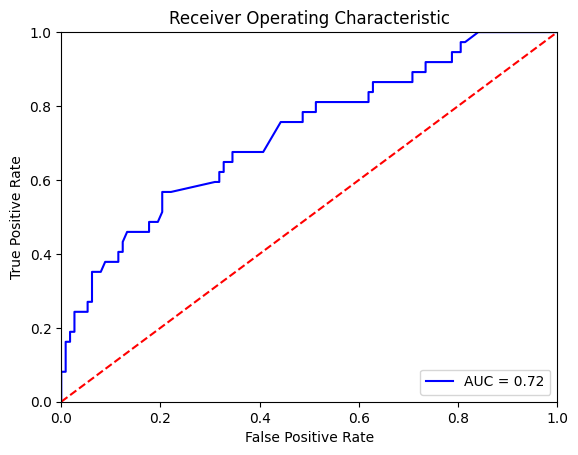

In [26]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [27]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.7226±0.0489',
 'F1': '0.4888±0.0736',
 'Accuracy': '0.7659±0.0341',
 'Precision': '0.5308±0.0860',
 'Recall': '0.4593±0.0829'}